## 1. Imports & Configs

In [ ]:
import h5py, torch, os, optuna, math
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy import stats
from scipy.signal import resample
from collections import defaultdict
from tqdm import tqdm
from typing import  Callable



H5_PATHS = {
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_phys.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_rppg.h5",
    "ecg_fitness": "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ecg_fitness.h5",
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/mcd_rppg.h5",
}

HR_MIN = 40.0
HR_MAX = 180.0 
MAX_NAN_FRAC = 0.10
TARGET_FRAMES = 240
WINDOW_SEC = 8
STRIDE_SEC = 4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5

print(f"Device: {DEVICE}")
print(f"Trials : {N_TRIALS} | Max epochs/trials {N_EPOCHS}")

Device: cuda
Trials : 50 | Max epochs/trials 50


## 2. Window extractor fuction

In [2]:
def extract_windows(rppg: np.ndarray, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int, target_frames: int, 
                    max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Extract sliding windows from one recording.

    Returns:
        windows : list of np.ndarray, each shape (target_frames,)
        labels : list of float, HR in BPM
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(rppg)

    windows = []
    labels = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames

        rppg_win = rppg[start:end]
        hr_win = hr_cont[start:end]

        # NaN check on label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue
        
        # Compute scalar HR label
        hr_label = float(np.nanmean(hr_win))

        # Physiological sanity check
        if not (hr_min <= hr_label <= hr_max):
            continue

        # NaN check on signal
        if np.any(np.isnan(rppg_win)):
            continue

        # Resample to fixed length
        if len(rppg_win) != target_frames:
            rppg_win = resample(rppg_win, target_frames).astype(np.float32)

        # Z-score normalisation per window
        std = rppg_win.std()
        if std < 1e-6:
            continue
        rppg_win = (rppg_win - rppg_win.mean()) / std

        windows.append(rppg_win.astype(np.float32))
        labels.append(hr_label)

    return windows, labels

## 3. Index builder

In [3]:
def build_index(h5_paths : dict[str, str], window_sec: int, stride_sec: int, target_frames: int,
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Returns: 
        samples : list of dicts with keys: signal, hr_label, subject_key, dataset
        subject_keys : sorted list of unique subject identifiers (dataset + subject_id)
    """
    samples = []
    subject_keys = set()

    for dataset_name, path in h5_paths.items():
        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]
                    fps = float(rec.attrs["fps"])
                    rppg = rec["rppg_signal"][:]
                    hr = rec["hr_continuous"][:]

                    wins, labels = extract_windows(rppg, hr, fps, window_sec,
                                                stride_sec, target_frames,
                                                max_nan_frac, hr_min, hr_max)

                    for win, label in zip(wins, labels):
                        samples.append({
                            "signal" : win,
                            "hr_label" : label,
                            "subject_key" : subj_key,
                            "dataset" : dataset_name
                        })

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    return samples, sorted(subject_keys)

## 4. Subject-level train/val/test split

In [4]:
def subject_split(subject_keys: list[str], train_frac: float = 0.70,  val_frac: float = 0.15,seed : int = 42) -> tuple:
    """
    Returns three sets of subject_key strings.
    test_frac = 1 - train_frac - val_frac.
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys : set[str] = set(keys[:n_train])
    val_keys : set[str] = set(keys[n_train : n_train + n_val])
    test_keys : set[str] = set(keys[n_train + n_val :])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset class

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase 2 rPPG -> HR estimation.
    
    Args: 
        samples : list of dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
    """
    def __init__(self, samples: list[dict], subject_set: set[str]) -> None:
        self.items: list[dict] = [sample for sample in samples if sample["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        item = self.items[idx]
        signal = torch.tensor(item["signal"], dtype=torch.float32).unsqueeze(0)
        # shape: (1, TARGET_Framse) - (channels, time)
        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label 


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Evaluation Functions

In [6]:
def compute_subject_level_metrics(preds : np.ndarray,labels : np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean),
    then compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _  = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae": mae, 
        "subj_rmse": rmse,
        "subj_r": r, 
        "ba_bias": ba_bias,
        "ba_loa_lo": ba_bias - 1.96*ba_sd,
        "ba_loa_hi": ba_bias + 1.96*ba_sd,
        "n_subjects": len(subj_pred_mean),
    }


def coverage_metrics(preds : np.ndarray, labels: np.ndarray,) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds : np.ndarray, labels : np.ndarray, dataset_ids: list[str]) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask  = np.array([d == ds for d in dataset_ids])
        p, l  = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae   = float(np.mean(np.abs(p - l)))
        rmse  = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _  = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds : np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae  = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels : np.ndarray, subject_ids: list, dataset_ids: list, model_name : str = "Model") -> None:

    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    # Window-level
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    # Coverage
    print()
    coverage_metrics(preds, labels)

    # Subject-level
    compute_subject_level_metrics(preds, labels, subject_ids)

    # Per-dataset
    per_dataset_metrics(preds, labels, dataset_ids)

    # HR-stratified
    hr_stratified_metrics(preds, labels)


## 7. Data Preparation

In [7]:
all_samples, all_subject_keys = build_index(H5_PATHS, WINDOW_SEC, STRIDE_SEC, TARGET_FRAMES, MAX_NAN_FRAC, HR_MIN, HR_MAX)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.70, val_frac = 0.15, seed=SEED)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys)

# Fixed loaders - reused by every trial
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

Total windows extracted : 9501
Total unique subjects : 194
Train subjects : 135
Val subjects : 29
Test subjects : 30

Train dataset:
Dataset size: 6656 windows
Val dataset:
Dataset size: 1421 windows
Test dataset:
Dataset size: 1424 windows


## 8. Model architecture

### Model A - CRVSETransformer

In [8]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding.
    Adds position information - Transformers have not inherent sense of temporal order without this.
    """
    def __init__(self, d_model: int, max_len: int = 300, dropout: float = 0.1) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0)) # (1, max_len, d_model)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerEncoderLayerCustom(nn.Module):
    """
    Replacement for nn.TransformerEncoderLayer.
    Avoids PyTorch 2.x dtype check bug on src_mask.
    Pre-norm architecture: more stable on small datasets.
    """
    def __init__(self, d_model: int, n_heads: int, dim_feedforward: int = 256, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % n_heads == 0, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"

        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5

        # Multi-head self-attention projections
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        # Feed-forward network
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def _attention(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape

        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V) # (B, H, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, -1) # (B, T, d_model)
        return self.out_proj(out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-norm residual
        x = x + self.dropout(self._attention(self.norm1(x)))
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x

class CRVSETransformer(nn.Module):
    """
    CNN encoder + standard global self-attention Transformer.
    
    The CNN extracts local pulse morphology features.
    The Transformer models global temporal dependencies -
    every timestep attends to every other timestep.
    
    Args:
        in_channels : input_channels
        cnn_channels : CNN output channels = Transformer d_model
        n_heads : attention heads (must divide cnn_channels)
        n_layers : Transformer encoder depth
        dim_feedforward : FFN hidden size (typically 4 x d_model)
        dropout : dropout throughout
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 64, n_heads: int = 4, n_layers: int = 2, 
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float= 180.0) -> None:
        super().__init__()
        assert cnn_channels % n_heads == 0, f"cnn_channels ({cnn_channels}) must be divisible by n_heads ({n_heads})"

        self.hr_min = hr_min
        self.hr_max = hr_max

        # CNN Encoder 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Positional Encoding 
        self.pos_enc = PositionalEncoding(cnn_channels, max_len=300, dropout=dropout)

        # Transformer layer
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderLayerCustom(
                d_model = cnn_channels,
                n_heads = n_heads,
                dim_feedforward = dim_feedforward,
                dropout = dropout,
            )
            for _ in range(n_layers)
        ])

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(cnn_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.encoder(x) # (B, C, T)
        out = out.permute(0, 2, 1) # (B, T, C)
        out = self.pos_enc(out)
        for layer in self.transformer_layers:
            out = layer(out)
        out = out.mean(dim=1)  # (B, C) — GAP over time
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model B - CRVSEPhysFormer

In [9]:
class CRVSEPhysFormer(nn.Module):
    """
    CNN + FFT + Transformer over frequency bins.
    
    rPPG-specific inductive bias: HR information lives in a narrow frequency band (0.7-3.5 Hz). 
    Attending over frequency components rather than raw time steps is more efficient - the model
    learns `which frequency bins is the pulse` directly.
    
    Pipeline:
        Conv encoder (time domain) -> local pulse features
        FFT magnitude -> frequency representation
        Concat [time_features, freq_features] per position
        Transformer over frequency bins
        GAP -> Head
        
    Args:
        in_channels : input_channels
        cnn_channels : CNN output = time feature dimension
        freq_channels : projection dimenstion for FFT features
        d_model : cnn_channels + freq_channels (transformer input)
        n_heads : attention heads (must divide d_model)
        n_layers : transformer depth
        dim_feedforward : FNN hidden size
        dropout : dropout throughout
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 32, freq_channels: int = 32, n_heads: int = 4, n_layers: int = 2, 
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        
        self.hr_min = hr_min
        self.hr_max = hr_max
        self.d_model = cnn_channels + freq_channels

        assert self.d_model % n_heads == 0, f"d_model ({self.d_model}) must be divisible by n_heads ({n_heads})"

        # CNN Encoder (time domain) 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # Output: (B, cnn_channels, T)

        # FFT frequency projection 
        # rfft of T=240 samples -> 121 frequency bins
        # Project each bin to freq_channels dimensions
        # then repeat across T time steps for concatenation
        n_fft_bins = TARGET_FRAMES // 2 + 1 # 121 for T=240
        self.freq_proj = nn.Sequential(
            nn.Linear(n_fft_bins, freq_channels * 4),
            nn.ReLU(),
            nn.Linear(freq_channels * 4, freq_channels),
        )

        # Positional encoding on d_model
        self.pos_enc = PositionalEncoding(self.d_model, max_len=300, dropout=dropout)

        self.transformer_layers = nn.ModuleList([
            TransformerEncoderLayerCustom(
                d_model = self.d_model,
                n_heads = n_heads,
                dim_feedforward = dim_feedforward,
                dropout = dropout,
            )
            for _ in range(n_layers)
        ])

        # Regression Head 
        self.head = nn.Sequential(
            nn.Linear(self.d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, T = x.shape

        # Time domain features 
        time_feat = self.encoder(x) # (B, cnn_channels, T)
        time_feat = time_feat.permute(0, 2, 1) # (B, T, cnn_channels)

        # Frequency domain features
        # rfft on the raw signal - magnitude spectrum
        freq = torch.fft.rfft(x.squeeze(1), norm="ortho")  # (B, n_fft_bins) complex
        freq_mag = freq.abs()  # (B, n_fft_bins) real
        freq_feat = self.freq_proj(freq_mag)  # (B, freq_channels)
        # Broadcast frequency features across all T time steps
        freq_feat = freq_feat.unsqueeze(1).expand(-1, T, -1)  # (B, T, freq_channels)

        # Concatenate time + frequency 
        combined = torch.cat([time_feat, freq_feat], dim=-1)  # (B, T, d_model)
        combined = self.pos_enc(combined)

        # Transformer
        for layer in self.transformer_layers:
            combined = layer(combined)
            
        out = combined.mean(dim=1)  # (B, d_model) — GAP  ← single mean
        out = self.head(out).squeeze(-1)  # (B,)

        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model C - CRVSELocalAttention

In [10]:
class LocalAttentionBlock(nn.Module):
    """
    Sliding window (local) self-attention block.
    
    Each timestep attends only to its local neighbourhood of ± window_size samples.
    Physiological justification: pulse wave features (systolic peak, dicrotic notch,
    inter-bear interval) are local phenomena within an 8-second rPPG window.
    
    Implementation: uses PyTorch's scaled_dot_product_attention with an attention mask
    that enforces locality.
    
    Args:
        d_model : feature dimension
        n_heads : attention heads
        window_size : each token attends to ± window_size neighbours
        dropout : dropout on attention weights
    """
    def __init__(self, d_model: int, n_heads: int, window_size: int = 15, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % n_heads == 0, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim  = d_model // n_heads
        self.window_size = window_size
        self.scale = self.head_dim ** -0.5
        self.dropout = nn.Dropout(dropout)

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def _build_local_mask(self, T: int, device: torch.device) -> torch.Tensor:
        """
        Boolean mask: True = attend, False = block.
        Shape: (T, T) - position i attends to j if |i-j| <= window_size
        """
        idx = torch.arange(T, device=device)
        dist = (idx.unsqueeze(0) - idx.unsqueeze(1)).abs() # (T, T)
        return dist <= self.window_size # (T, T) bool

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        B, T, _ = x.shape

        Q = self.q_proj(x) # (B, T, d_model)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Reshape to multi-head: (B, n_heads, T, head_dim)
        def split_heads(t: torch.Tensor) -> torch.Tensor:
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, T, T)

        # Apply local mask — block attention outside window
        local_mask = self._build_local_mask(T, x.device) # (T, T)
        # Convert to additive mask: 0 where attend, -inf where block
        additive_mask = torch.zeros(T, T, device=x.device)
        additive_mask[~local_mask] = float("-inf")
        scores = scores + additive_mask.unsqueeze(0).unsqueeze(0) # broadcast

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V) # (B, H, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.out_proj(out)

        

class LocalAttentionEncoderLayer(nn.Module):
    """
    Full encoder layer: LocalAttention + FNN + residuals + LayerNorm.
    Mirrors nn.TransformerEncoderLayer but with local attention.
    """
    def __init__(self, d_model: int, n_heads: int, window_size: int = 15, dim_feedforward: int = 256, dropout: float = 0.1) -> None:
        super().__init__()
        self.attn = LocalAttentionBlock(d_model, n_heads, window_size, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-norm residual (more stable than post-norm for small datasets)
        x = x + self.dropout(self.attn(self.norm1(x)))
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x


class CRVSELocalAttention(nn.Module):
    """
    CNN encoder + stacked local (sliding window) attention layers.
    
    Args:
        in_channels : input_channels
        cnn_channels : CNN output = d_model
        n_heads : attention heads
        n_layers : number of local attention layers
        window_size : local attention radius in samples
        dim_feedforward : FNN hiden size
        dropout : dropout throughout
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 64, n_heads: int = 4, n_layers: int = 2, window_size: int = 15,
                dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        assert cnn_channels % n_heads == 0, f"cnn_channels ({cnn_channels}) must be divisible by n_heads ({n_heads})"

        self.hr_min = hr_min
        self.hr_max = hr_max

        #  CNN Encoder 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Positional Encoding 
        self.pos_enc = PositionalEncoding(cnn_channels, max_len=300, dropout=dropout)

        # Local Attention Stack
        self.layers = nn.ModuleList([
            LocalAttentionEncoderLayer(
                d_model = cnn_channels,
                n_heads = n_heads,
                window_size = window_size,
                dim_feedforward = dim_feedforward,
                dropout = dropout,
            )
            for _ in range(n_layers)
        ])

        # Regression Head 
        self.head = nn.Sequential(
            nn.Linear(cnn_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.encoder(x) # (B, C, T)
        out = out.permute(0, 2, 1) # (B, T, C)
        out = self.pos_enc(out)
        for layer in self.layers:
            out = layer(out) # (B, T, C)
        out = out.mean(dim=1) # (B, C) — GAP
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out
    

In [11]:
# Models sanity checks
dummy = torch.randn(32, 1, 240)

configs = [
    ("CRVSETransformer", CRVSETransformer(cnn_channels=64, n_heads=4, n_layers=2)),
    ("CRVSEPhysFormer", CRVSEPhysFormer(cnn_channels=32, freq_channels=32, n_heads=4, n_layers=2)),
    ("CRVSELocalAttention",CRVSELocalAttention(cnn_channels=64, n_heads=4, n_layers=2, window_size=15)),
]

print(f"{'Model':<25} {'Output':>14} {'Params':>12}")
print("-" * 55)
for name, model in configs:
    with torch.no_grad():
        out = model(dummy)
    params = count_parameters(model)
    print(f"{name:<25} {str(out.shape):>14} {params:>12,}")

Model                             Output       Params
-------------------------------------------------------
CRVSETransformer          torch.Size([32])      125,313
CRVSEPhysFormer           torch.Size([32])      127,809
CRVSELocalAttention       torch.Size([32])      125,313


## 9. Shared Optuna objective factory

In [12]:
def make_objective(model_class : type, search_space: Callable[[optuna.Trial], dict]) -> Callable[[optuna.Trial], float]:
    """
    Factory function that returns an Optuna objective function for any model class:
    
    Args:
        model_class : the nn.Module class to instantiate
        search_space : function that takes a trial and returns a dict of architecture kwargs
    
    Returns:
        objective function compatible with study.optimize()
        
    """
    def objective(trial: optuna.Trial) -> float:
        # Tier 1
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

        # Tier 2 — model-specific architecture params
        arch_kwargs = search_space(trial)

        # Build model 
        model = model_class(
            in_channels = 1,
            dropout = dropout,
            hr_min = HR_MIN,
            hr_max = HR_MAX,
            **arch_kwargs,
        ).to(DEVICE)

        loss_fnunction  = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

        best_val_mae = float("inf")

        for epoch in range(1, N_EPOCHS + 1):
            # Train
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                preds = model(signals)
                loss  = loss_fnunction(preds, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # Validate
            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    preds  = model(signals)
                    total_mae += torch.mean(torch.abs(preds - labels)).item()

            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective
    
        

In [13]:
# Architecture-specific search spaces
def search_space_transformer(trial: optuna.Trial) -> dict:
    cnn_channels = trial.suggest_categorical("cnn_channels", [32, 64, 128])
    n_heads = trial.suggest_categorical("n_heads", [2, 4])
    cnn_channels = (cnn_channels // n_heads) * n_heads   # ensure divisibility
    return {
        "cnn_channels" : cnn_channels,
        "n_heads" : n_heads,
        "n_layers" : trial.suggest_int("n_layers", 1, 4),
        "dim_feedforward" : cnn_channels * trial.suggest_categorical("ff_mult", [2, 4, 8]),
    }

def search_space_physformer(trial: optuna.Trial) -> dict:
    cnn_channels  = trial.suggest_categorical("cnn_channels", [16, 32, 64])
    freq_channels = trial.suggest_categorical("freq_channels", [16, 32, 64])
    n_heads = trial.suggest_categorical("n_heads", [2, 4])
    d_model = cnn_channels + freq_channels
    d_model = (d_model // n_heads) * n_heads   # snap to divisible
    # Recompute freq_channels to match snapped d_model
    freq_channels = d_model - cnn_channels
    if freq_channels < 4:
        freq_channels = 4
    return {
        "cnn_channels" : cnn_channels,
        "freq_channels" : freq_channels,
        "n_heads" : n_heads,
        "n_layers" : trial.suggest_int("n_layers", 1, 4),
        "dim_feedforward" : d_model * trial.suggest_categorical("ff_mult", [2, 4]),
    }

def search_space_local(trial: optuna.Trial) -> dict:
    cnn_channels = trial.suggest_categorical("cnn_channels", [32, 64, 128])
    n_heads = trial.suggest_categorical("n_heads", [2, 4])
    cnn_channels = (cnn_channels // n_heads) * n_heads
    return {
        "cnn_channels" : cnn_channels,
        "n_heads" : n_heads,
        "n_layers" : trial.suggest_int("n_layers", 1, 4),
        "window_size" : trial.suggest_categorical("window_size", [8, 15, 30]),
        "dim_feedforward" : cnn_channels * trial.suggest_categorical("ff_mult", [2, 4]),
    }



def make_progress_callback(name: str) -> Callable:
    """
    Returns a callback that prints one visible line per completed/pruned trial.
    Replaces the silent tqdm progress bar with per-trial output.
    """
    def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
        if trial.state == optuna.trial.TrialState.PRUNED:
            status = "PRUNED      "
        else:
            status = f"{trial.value:.3f} BPM"
        best = study.best_value
        p = trial.params
        print(
            f"[{name}] Trial {trial.number:>3} | val MAE : {status} | "
            f"best : {best:.3f} BPM | lr={p.get('lr','?'):.1e} wd={p.get('weight_decay','?'):.1e}"
            f"drop={p.get('dropout','?'):.2f} cnn_ch={p.get('cnn_channels','?')} "
            f"n_heads={p.get('n_heads','?')} n_layers={p.get('n_layers','?')}"
        )
    return progress_callback
    
# Shared study runner 
def run_study(name: str, model_class: type, search_space: Callable) -> optuna.Study:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction = "minimize",
        sampler = TPESampler(seed=SEED),
        pruner = MedianPruner(n_startup_trials = 5, n_warmup_steps = PRUNER_WARMUP,interval_steps = 1),
        study_name = name,
    )

    print(f"\nStarting study: {name}")
    print(f"{N_TRIALS} trials | up to {N_EPOCHS} epochs each")
    print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup=5 trials)")
    print("  " + "─" * 70)

    study.optimize(make_objective(model_class, search_space), n_trials = N_TRIALS,
                   callbacks = [make_progress_callback(name)], show_progress_bar = False)

    n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

    print("  " + "─" * 70)
    print(f"STUDY COMPLETE  |  best val MAE: {study.best_value:.3f} BPM | trial #{study.best_trial.number}")
    print(f"Completed: {n_complete} | Pruned: {n_pruned}")
    print(f"\n Best hyperparameters:")
    for key, value in study.best_params.items():
        if isinstance(value, float):
            print(f"{key:<20} : {value:.4e}" if value < 0.01 else f"{key:<20} : {value:.4f}")
        else:
            print(f"{key:<20} : {value}")
    return study

## 10. Optuna Hyperparamter Studies

In [14]:
# Run Model A
print("=" * 50)
print("ROUND 3A - CRVSETransformer")
print("=" * 50)
study_transformer = run_study(
    "crvse_transformer",
    CRVSETransformer,
    search_space_transformer,
)

ROUND 3A - CRVSETransformer

Starting study: crvse_transformer
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[crvse_transformer] Trial   0 | val MAE : 4.933 BPM | best : 4.933 BPM | lr=2.4e-04 wd=7.1e-03drop=0.32 cnn_ch=32 n_heads=2 n_layers=3
[crvse_transformer] Trial   1 | val MAE : 3.973 BPM | best : 3.973 BPM | lr=1.6e-04 wd=3.5e-05drop=0.16 cnn_ch=32 n_heads=2 n_layers=2
[crvse_transformer] Trial   2 | val MAE : 4.521 BPM | best : 3.973 BPM | lr=1.6e-04 wd=3.5e-04drop=0.28 cnn_ch=32 n_heads=4 n_layers=4
[crvse_transformer] Trial   3 | val MAE : 4.097 BPM | best : 3.973 BPM | lr=2.8e-04 wd=2.3e-05drop=0.25 cnn_ch=32 n_heads=4 n_layers=3
[crvse_transformer] Trial   4 | val MAE : 4.178 BPM | best : 3.973 BPM | lr=8.7e-04 wd=4.8e-03drop=0.28 cnn_ch=64 n_heads=4 n_layers=2
[crvse_transformer] Trial   5 | val MAE : PRUNED       | best : 3.973 BPM | lr=3.5e-04 wd=2.6e-05dr

In [15]:
# Run Model B
print("=" * 50)
print("ROUND 3B - CRVSEPhysFormer")
print("=" * 50)
study_physformer = run_study(
    "crvse_physformer",
    CRVSEPhysFormer,
    search_space_physformer,
)

ROUND 3B - CRVSEPhysFormer

Starting study: crvse_physformer
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[crvse_physformer] Trial   0 | val MAE : 3.843 BPM | best : 3.843 BPM | lr=2.4e-04 wd=7.1e-03drop=0.32 cnn_ch=16 n_heads=4 n_layers=4
[crvse_physformer] Trial   1 | val MAE : 3.676 BPM | best : 3.676 BPM | lr=1.5e-04 wd=8.2e-05drop=0.26 cnn_ch=32 n_heads=2 n_layers=3
[crvse_physformer] Trial   2 | val MAE : 3.519 BPM | best : 3.519 BPM | lr=4.1e-04 wd=3.2e-05drop=0.12 cnn_ch=16 n_heads=4 n_layers=1
[crvse_physformer] Trial   3 | val MAE : 5.938 BPM | best : 3.519 BPM | lr=4.6e-04 wd=8.6e-05drop=0.26 cnn_ch=32 n_heads=2 n_layers=1
[crvse_physformer] Trial   4 | val MAE : 5.552 BPM | best : 3.519 BPM | lr=2.4e-04 wd=6.5e-05drop=0.35 cnn_ch=32 n_heads=2 n_layers=1
[crvse_physformer] Trial   5 | val MAE : 3.202 BPM | best : 3.202 BPM | lr=5.4e-04 wd=2.1e-03drop=0.12 cnn

In [16]:
# Run Model C
print("=" * 50)
print("ROUND 3C - CRVSELocalAttention")
print("=" * 50)
study_local = run_study(
    "crvse_local_attention",
    CRVSELocalAttention,
    search_space_local,
)

ROUND 3C - CRVSELocalAttention

Starting study: crvse_local_attention
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[crvse_local_attention] Trial   0 | val MAE : 5.056 BPM | best : 5.056 BPM | lr=2.4e-04 wd=7.1e-03drop=0.32 cnn_ch=32 n_heads=2 n_layers=3
[crvse_local_attention] Trial   1 | val MAE : 4.342 BPM | best : 4.342 BPM | lr=1.5e-04 wd=8.2e-05drop=0.26 cnn_ch=64 n_heads=4 n_layers=2
[crvse_local_attention] Trial   2 | val MAE : 3.842 BPM | best : 3.842 BPM | lr=4.1e-04 wd=3.2e-05drop=0.12 cnn_ch=32 n_heads=4 n_layers=2
[crvse_local_attention] Trial   3 | val MAE : 4.484 BPM | best : 3.842 BPM | lr=4.6e-04 wd=8.6e-05drop=0.26 cnn_ch=64 n_heads=2 n_layers=3
[crvse_local_attention] Trial   4 | val MAE : 4.649 BPM | best : 3.842 BPM | lr=2.4e-04 wd=6.5e-05drop=0.35 cnn_ch=64 n_heads=2 n_layers=4
[crvse_local_attention] Trial   5 | val MAE : 3.842 BPM | best : 3.842 B

## 11. Study Visualisations

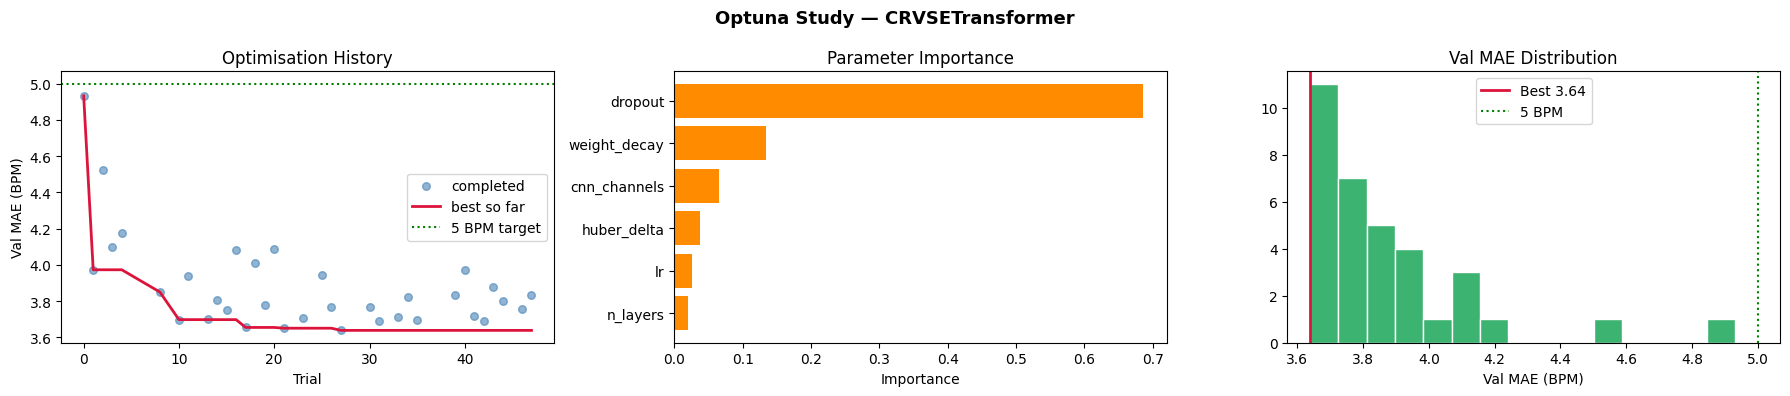

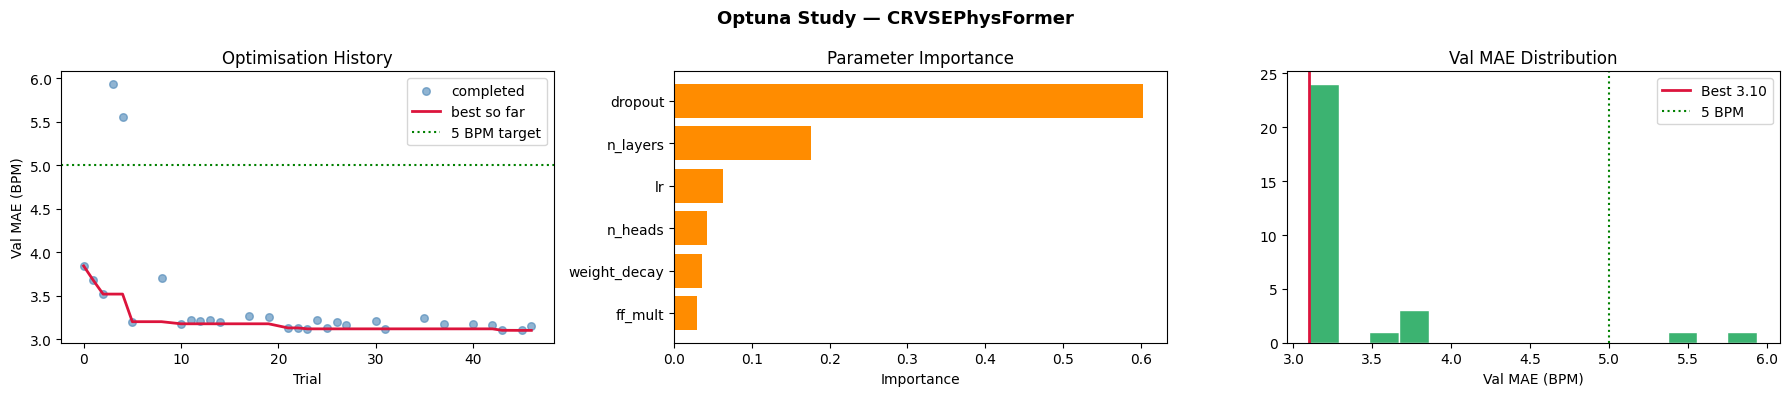

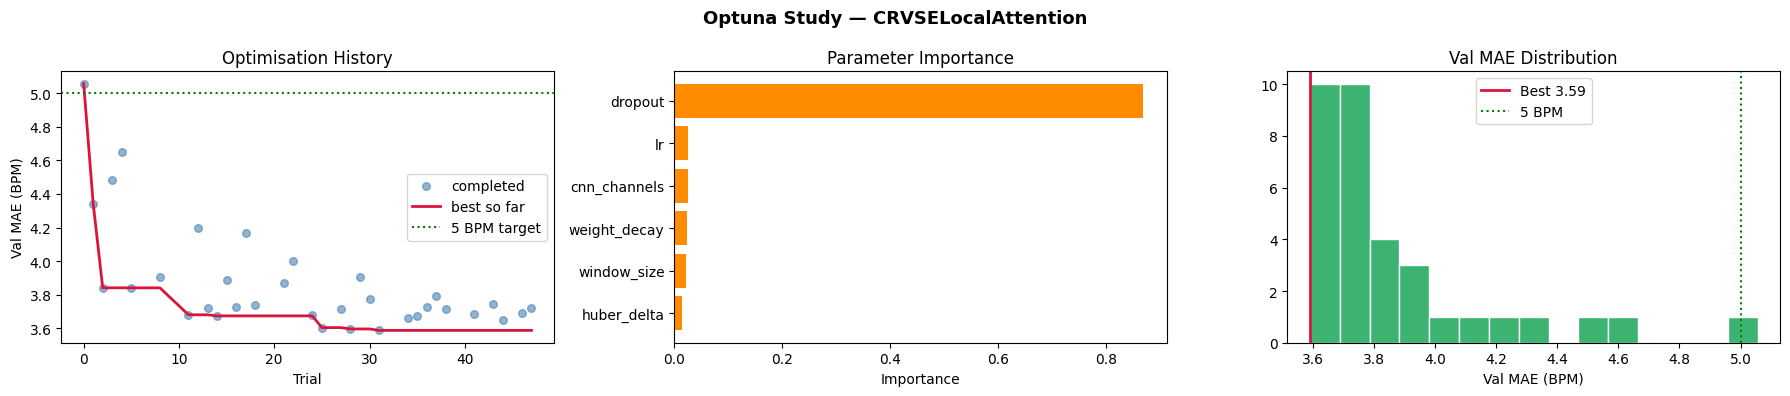

In [17]:
def plot_study(study: optuna.Study, arch_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value  for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Optuna Study — {arch_name}", fontweight="bold", fontsize=13)

    # Panel - optimisation history
    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial")
    axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History")
    axes[0].legend()

    # Panel - parameter importance
    try:
        importances = optuna.importance.get_param_importances(study)
        top = list(importances.items())[:6]
        params, imps = zip(*top)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance")
        axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Not available", ha="center", va="center", transform=axes[1].transAxes)

    # Panel - val MAE distribution
    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM")
    axes[2].set_xlabel("Val MAE (BPM)")
    axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"optuna_{arch_name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Plot all three studies after they complete 
for arch_name, study in [("CRVSETransformer", study_transformer), ("CRVSEPhysFormer", study_physformer),
                         ("CRVSELocalAttention",study_local)]:
    plot_study(study, arch_name)

## 12. Train model on best configuration (training on full train + val, evaluation on test set)

In [18]:
def retrain_best(name: str, model_class: type, study: optuna.Study, arch_keys: list[str], save_path: str) -> nn.Module:
    """
    Retrain best trial config on train+val, evaluate on test.
    Returns the trained model.
    """
    p = study.best_params
    best_n_epochs = study.best_trial.last_step

    print(f"\n{'='*50}")
    print(f"Retraining {name}")
    print(f"Best trial epoch : {best_n_epochs}")
    print(f"{'='*50}")

    arch_kwargs = {key: p[key] for key in arch_keys if key in p}

    model = model_class(
        in_channels = 1,
        dropout = p["dropout"],
        hr_min = HR_MIN,
        hr_max = HR_MAX,
        **arch_kwargs,
    ).to(DEVICE)

    full_ds = CRVSEDataset(all_samples, train_keys | val_keys)
    full_loader = DataLoader(
        full_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=2, pin_memory=True
    )

    loss_function = nn.HuberLoss(delta=p["huber_delta"])
    optimizer = AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

    epoch_bar = tqdm(range(1, best_n_epochs + 1), desc = f"Training {name}", unit = "epoch")
    for epoch in epoch_bar:
        model.train()
        total_loss = 0.0
        for signals, labels in full_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(signals)
            loss  = loss_function(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        epoch_bar.set_postfix({"loss": f"{total_loss / len(full_loader):.3f}"})

    torch.save({
        "best_params" : p,
        "best_n_epochs" : best_n_epochs,
        "model_state" : model.state_dict(),
    }, save_path)
    print(f"Saved → {save_path}")

    return model


# Architecture keys per model 
TRANSFORMER_ARCH_KEYS = ["cnn_channels", "n_heads", "n_layers", "dim_feedforward"]
PHYSFORMER_ARCH_KEYS  = ["cnn_channels", "freq_channels", "n_heads", "n_layers", "dim_feedforward"]
LOCAL_ARCH_KEYS  = ["cnn_channels", "n_heads", "n_layers", "window_size", "dim_feedforward"]

model_transformer = retrain_best(
    "CRVSETransformer", CRVSETransformer,
    study_transformer, TRANSFORMER_ARCH_KEYS,
    "crvse_transformer_best.pt"
)
model_physformer = retrain_best(
    "CRVSEPhysFormer", CRVSEPhysFormer,
    study_physformer, PHYSFORMER_ARCH_KEYS,
    "crvse_physformer_best.pt"
)
model_local = retrain_best(
    "CRVSELocalAttention", CRVSELocalAttention,
    study_local, LOCAL_ARCH_KEYS,
    "crvse_local_attention_best.pt"
)


Retraining CRVSETransformer
Best trial epoch : 50
Dataset size: 8077 windows


Training CRVSETransformer: 100%|██████████| 50/50 [06:32<00:00,  7.86s/epoch, loss=27.503]


Saved → crvse_transformer_best.pt

Retraining CRVSEPhysFormer
Best trial epoch : 50
Dataset size: 8077 windows


Training CRVSEPhysFormer: 100%|██████████| 50/50 [04:21<00:00,  5.23s/epoch, loss=19.744]


Saved → crvse_physformer_best.pt

Retraining CRVSELocalAttention
Best trial epoch : 50
Dataset size: 8077 windows


Training CRVSELocalAttention: 100%|██████████| 50/50 [06:10<00:00,  7.41s/epoch, loss=29.783]

Saved → crvse_local_attention_best.pt


## 13. Full evaluation all 3 models

In [19]:
def collect_predictions(model: nn.Module, loader: DataLoader, ds: CRVSEDataset) -> tuple[np.ndarray, np.ndarray, list[str], list[str]]:
    """Collect predictions, labels, subject_ids, dataset_ids from a loader."""
    model.eval()
    preds_list, labels_list = [], []

    with torch.inference_mode():
        for signals, labels in loader:
            preds = model(signals.to(DEVICE)).cpu().numpy()
            preds_list.extend(preds.tolist())
            labels_list.extend(labels.numpy().tolist())

    subject_ids = [ds.items[i]["subject_key"] for i in range(len(ds))]
    dataset_ids = [ds.items[i]["dataset"] for i in range(len(ds))]

    return (
        np.array(preds_list,  dtype=np.float32),
        np.array(labels_list, dtype=np.float32),
        subject_ids,
        dataset_ids,
    )


# Evaluate all 3
results = {}

for name, model in [("CRVSETransformer", model_transformer), ("CRVSEPhysFormer", model_physformer), ("CRVSELocalAttention", model_local)]:
    preds, labels, subj_ids, ds_ids = collect_predictions(model, test_loader, test_ds)
    full_evaluation(preds = preds, labels = labels, subject_ids = subj_ids, dataset_ids = ds_ids, model_name = name)
    # Store for comparison table
    results[name] = {
        "preds" : preds,
        "labels" : labels,
        "subj" : subj_ids,
        "ds" : ds_ids,
    }


FULL EVALUATION - CRVSETransformer

Window-level (n=1424 windows):
MAE : 3.23 BPM
RMSE : 5.15 BPM
MAPE : 4.25 %
Pearson r : 0.9336  (p=0.0000)
R² : 0.8620
BA bias : 1.03 BPM
BA LoA : [-8.85, 10.92] BPM

|error| <  5 BPM : 81.5% of windows
|error| < 10 BPM : 94.3% of windows
|error| < 15 BPM : 97.5% of windows

Subject-level metrics (n=29 subjects):
MAE : 2.27 BPM
RMSE : 3.35 BPM
r : 0.9818
BA bias: 1.25 BPM
BA LoA : [-4.83, 7.34] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
mcd_rppg         1174     2.73     3.94   0.8928
ubfc_phys         175     5.80     8.73   0.6429
ubfc_rppg          75     5.06     9.04   0.7494

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     3.09     4.42
normal low               833     3.01     5.12
normal high              178     4.83     6.78
tachycardia/exercise     129     2.

## 14. Round 3 internal comparison table

In [20]:
def round3_comparison(results: dict) -> str:
    """
    Print Round 3 comparison table and return name of best model.
    """
    print("\n" + "=" * 65)
    print("ROUND 3 — TRANSFORMER VARIANTS COMPARISON")
    print("=" * 65)

    rows = {}
    for name, r in results.items():
        diff = r["preds"] - r["labels"]
        mae = float(np.mean(np.abs(diff)))
        rmse  = float(np.sqrt(np.mean(diff ** 2)))
        pearr,_ = stats.pearsonr(r["preds"], r["labels"])
        r2 = float(1 - np.sum(diff**2) / np.sum((r["labels"] - r["labels"].mean())**2))
        ba_bias = float(diff.mean())
        ba_sd = float(diff.std())
        cov5 = float(np.mean(np.abs(diff) < 5) * 100)
        rows[name] = dict(mae=mae, rmse=rmse, r=pearr, r2=r2, ba_bias=ba_bias, ba_sd=ba_sd, cov5=cov5)

    # Print table
    hdr = f"{'Model':<25} {'MAE':>6} {'RMSE':>6} {'r':>7} {'R²':>7} {'BA bias':>8} {'<5BPM%':>8}"
    print(hdr)
    print("  " + "-" * 65)
    for name, m in rows.items():
        print(f"{name:<25} {m['mae']:>6.2f} {m['rmse']:>6.2f} {m['r']:>7.4f} {m['r2']:>7.4f}{m['ba_bias']:>8.2f} {m['cov5']:>7.1f}%")

    best_name = min(rows, key=lambda n: rows[n]["mae"])
    print(f"\nBest Round 3 model : {best_name} (MAE {rows[best_name]['mae']:.2f} BPM)")
    return best_name

best_r3 = round3_comparison(results)


ROUND 3 — TRANSFORMER VARIANTS COMPARISON
Model                        MAE   RMSE       r      R²  BA bias   <5BPM%
  -----------------------------------------------------------------
CRVSETransformer            3.23   5.15  0.9336  0.8620    1.03    81.5%
CRVSEPhysFormer             3.15   5.45  0.9320  0.8452    1.78    84.5%
CRVSELocalAttention         3.36   5.23  0.9357  0.8576    1.57    80.3%

Best Round 3 model : CRVSEPhysFormer (MAE 3.15 BPM)
